In [1]:
import os
import torch
import torchvision
import mlflow
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from PIL import Image
from datetime import datetime
from torchvision.utils import save_image

# Special imports of above dependencies:
import torchvision.transforms as T
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

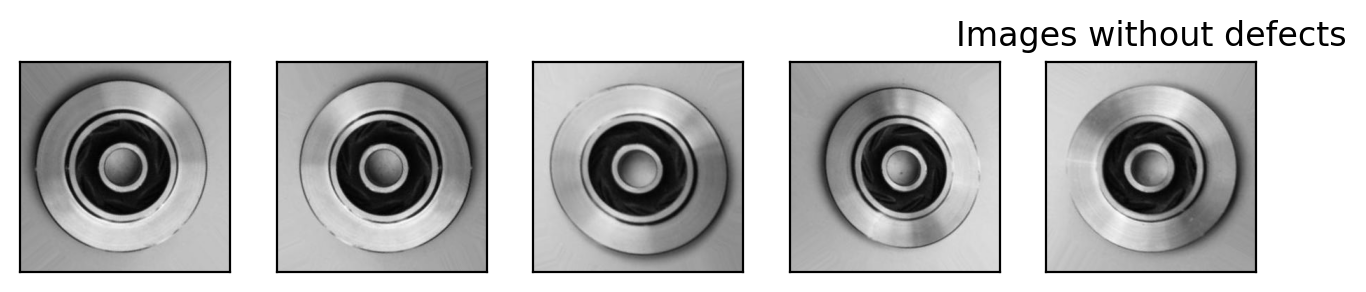

In [2]:
# Showing some samples of the dataset:

dataset_path_norm = "../data/raw/casting/casting_data/casting_data/train/ok_front/" # Path to GOOD images dataset
dataset_path_def  = "../data/raw/casting/casting_data/casting_data/train/def_front/" # Path to DEFECT images dataset
dataset_path_root = "../data/raw/casting/casting_data/casting_data/train/"


imgs_norm = os.listdir(os.path.join(dataset_path_norm)) # GOOD images
imgs_def  = os.listdir(os.path.join(dataset_path_def))  # DEFECT images

random.seed(42)

# Randomly sample 5 images per category:
samples_norm = random.sample(imgs_norm, 5)
samples_def  = random.sample(imgs_def, 5)

fig = plt.figure(dpi=200, figsize=(8, 3))

for i in range(len(samples_norm)):
    ax = plt.subplot(2, 5, i + 1)
    imgNormPlot = Image.open(os.path.join(dataset_path_norm, samples_norm[i]))
    plt.imshow(imgNormPlot, cmap='gray')
    plt.xticks([])
    plt.yticks([])

plt.title("Images without defects", loc='center')
plt.show()

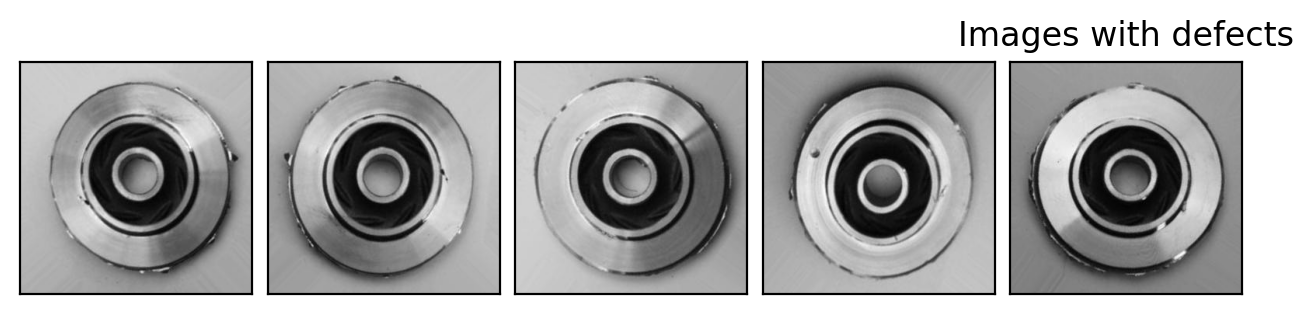

In [3]:
fig = plt.figure(dpi=200, figsize=(8, 3))

for i in range (len(samples_def)):
    ax = plt.subplot(2, 5, i + 6)
    imgDefPlot = Image.open(os.path.join(dataset_path_def, samples_def[i]))
    plt.imshow(imgDefPlot, cmap='gray')
    plt.xticks([])
    plt.yticks([])

plt.subplots_adjust(wspace=-0.01, hspace=-0.01)

plt.title('Images with defects')
plt.show()

In [4]:
# Detecting if a GPU is available:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device used: {torch.cuda.get_device_name(0)}") if device == "cuda" else print("No GPU available: Using CPU")

Device used: NVIDIA GeForce RTX 5080


In [5]:
# Defining the architecture for the CVAE (Generator in GAN):

# ############################################################################################################
# ####################################### Architecture of the Encoder: #######################################
# ############################################################################################################

class Encoder(nn.Module):
    def __init__(self, latent_dims=100, num_classes=2):
        super().__init__()

        self.num_classes = num_classes

        input_channels = 3 + num_classes # For the conditional label
        
        self.conv1 = nn.Conv2d(input_channels, 32, 3, stride=2, padding=1) # Input: 3x64x64 -> Output: 32x32x32
        self.batch1 = nn.BatchNorm2d(32) # Normalization 2D
        self.conv2 = nn.Conv2d(32, 64, 3, stride=2, padding=1) # Input: 32x32x32 -> Output: 64x16x16
        self.batch2 = nn.BatchNorm2d(64) # Normalization 2D
        self.conv3 = nn.Conv2d(64, 128, 3, stride=2, padding=1) # Input: 64x16x16 -> Output: 128x8x8
        self.batch3 = nn.BatchNorm2d(128) # Normalizarion 2D
        self.linear = nn.Linear(8*8*128, 1024) # Fully connected layer
        self.batch_linear = nn.BatchNorm1d(1024) # Normalization 1D

        self.linear_mu = nn.Linear(1024, latent_dims) # Fully connected layer for mean
        self.linear_log_var = nn.Linear(1024, latent_dims) # Fully connected layer for log variance

        # self.N = torch.distributions.Normal(0, 1) # Stardard normal distribution
        # self.N.loc = self.N.loc.cuda() # Move to GPU if available
        # self.N.scale.cuda() # Move to GPU id available

    def forward(self, x, label):
        # x = x.to(device) # Move input to GPU or CPU

        label_channel = label.unsqueeze(2).unsqueeze(3) # Expand dimensions: label_channel =  [1, 2, 1, 1] while x = [1, 3, 64,64]
        label_channel = label_channel.expand(x.size(0), self.num_classes, x.size(2), x.size(3)) # label_channel = [1, 2, 64, 64]
 
        x = torch.cat((x, label_channel), dim=1) # Concatenate label to original image in dim 1 (channels): x = [1, 5, 64, 64]


        x = F.relu(self.batch1(self.conv1(x))) # -> 32x32
        x = F.relu(self.batch2(self.conv2(x))) # -> 16x16
        x = F.relu(self.batch3(self.conv3(x))) # -> 8x8

        x = torch.flatten(x, start_dim=1)
        x = F.relu(self.batch_linear(self.linear(x)))

        mu = self.linear_mu(x)              # Compute mean
        log_var = self.linear_log_var(x)    # Compute log variance

        return mu, log_var

# Defining the architecture for the CNN (Discriminator in GAN):

# ############################################################################################################
# ####################################### Architecture of the Decoder: #######################################
# ############################################################################################################

class Decoder(nn.Module):
    # Recieve HP_LATENT_DIMS from __init__ of VAE
    def __init__(self, latent_dims, num_classes=2):
        super().__init__()

        self.num_classes = num_classes

        input_dim = latent_dims + self.num_classes

        # --- Linear layers (BatchNorm1d) ---
        self.linear1 = nn.Linear(input_dim, 1024)
        self.batch_linear1 = nn.BatchNorm1d(1024)
        self.linear2 = nn.Linear(1024, 8*8*128)
        self.batch_linear2 = nn.BatchNorm1d(8*8*128)
        
        self.unflatten = nn.Unflatten(dim=1, unflattened_size=(128, 8, 8))

        # --- ConvTranspose Layers (con BatchNorm2d) ---
        self.convT1 = nn.ConvTranspose2d(128 + self.num_classes, 64, 3, stride=2, padding=1, output_padding=1)
        self.batchT1 = nn.BatchNorm2d(64)
        self.convT2 = nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1)
        self.batchT2 = nn.BatchNorm2d(32)

        # Last layer with no BatchNorm
        self.convT3 = nn.ConvTranspose2d(32, 3, 3, stride=2, padding=1, output_padding=1)
        
    def forward(self, z, label):
        # z = z.to(device)
        z_conditional = torch.cat((z, label), dim=1)

        # Lineal
        x = F.relu(self.batch_linear1(self.linear1(z_conditional)))
        x = F.relu(self.batch_linear2(self.linear2(x)))
        
        x = self.unflatten(x)

        # Begin TODO: Test - Erase if don't work as expected:
        label_spatial = label.unsqueeze(2).unsqueeze(3).expand(x.size(0), self.num_classes, 8, 8)
        x = torch.cat((x, label_spatial * 10), dim=1) # [batch, 128+20, 8, 8]

        # End TODO
        
        # ConvTranspose
        x = F.relu(self.batchT1(self.convT1(x)))
        x = F.relu(self.batchT2(self.convT2(x)))
        
        # Final Layer:
        x = self.convT3(x)
        x = torch.tanh(x) # Output [-1, 1]
        # x = torch.sigmoid(x) # Output  [0, 1]

        return x
    
class CVAE(nn.Module):
    def __init__(self, latent_dims=100, num_classes=2):
        super().__init__()
        self.encoder = Encoder(latent_dims, num_classes)
        self.decoder = Decoder(latent_dims, num_classes)

    def reparametrize(self, mu, log_var):
        std = torch.exp(0.5 * log_var) # Compute standard deviation from log variance
        eps = torch.randn_like(std) # Sample form standard normal distribution

        return mu + eps * std
    
    def forward(self, x, label):
        #x = x.to(device)

        mu, log_var = self.encoder(x, label)
        z = self.reparametrize(mu, log_var)

        return self.decoder(z, label), mu, log_var
    
# ##################################################################################################################
# ####################################### Architecture of the Discriminator: #######################################
# ##################################################################################################################

class Discriminator(nn.Module):
    def __init__(self, nc=3, ndf=64, num_classes=2):
        super(Discriminator, self).__init__()

        self.num_classes = num_classes
        input_channels = nc + num_classes

        self.main = nn.Sequential(
            # Layer 1:
            nn.Conv2d(input_channels, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            # Layer 2:
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),

            # Layer 3:
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),

            # Layer 4:
            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),

            # Output layer:
            nn.Conv2d(ndf * 8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid() # Comment when using MSELoss
        )

    def forward(self, x, label):
        label_channel = label.unsqueeze(2).unsqueeze(3) # Expand dimensions: label_channel =  [1, 2, 1, 1] while x = [1, 3, 64,64]
        label_channel = label_channel.expand(x.size(0), self.num_classes, x.size(2), x.size(3)) # label_channel = [1, 2, 64, 64]

        x = torch.cat((x, label_channel), dim=1) # Concatenate label to original image in dim 1 (channels): x = [1, 5, 64, 64]

        output = self.main(x)

        return output.view(-1).squeeze()

In [6]:
# ######################################################################
# ######################### Training Function ##########################
# ######################################################################

def train_cvae_gan_epoch(
        dataloader,
        cvae,
        discriminator,
        optimizer_cvae,
        optimizer_discriminator,
        device,
        epoch,
        warmup_epochs,
        beta,
        gamma
):
    # Error accumlators:
    total_recon_loss = 0
    total_kld_loss = 0
    total_gan_loss = 0
    total_disc_loss = 0

    # Loss function for discriminator:
    criterion_gan = nn.BCELoss() # Binary Cross Entropy (when using Sigmoid)

    # Set networks on training mode:
    cvae.train()
    discriminator.train()

    for _, (images, labels_idx) in enumerate(dataloader):

        # Prepare data:
        images = images.to(device) # [batch, 3, 64, 64]
        labels_idx = labels_idx.to(device) # [barch] (int: 0, 1)

        # Encode labels: [0, 1] -> [[1, 0], [0, 1]]
        labels_encoded = F.one_hot(labels_idx, num_classes=2).float().to(device)

        # Get the batch size:
        batch_size = images.size(0)

        # ############################################################################
        # ######################## TRAINING GENERATOR (CVAE): ########################
        # ############################################################################
        optimizer_cvae.zero_grad() # Clean gradients

        recon_images, mu, log_var = cvae(images, labels_encoded)

        loss_recon = F.mse_loss(recon_images, images, reduction='sum') / batch_size # MSE loss for tanh
        loss_kld = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp()) / batch_size # Kullback-Leibler Divergence for std dist of latent space
        loss_gan = torch.tensor(0.0, device=device)

        # Activate GAN only if epoch >= warmup epochs:
        if epoch >= warmup_epochs:
            # Deactivate gradients for distriminator:
            for param in discriminator.parameters():
                param.requires_grad = False
                
            # Give reconstructed images and real label to discriminator:
            pred_fake = discriminator(recon_images, labels_encoded)

            # Trick: discriminator will recieve the predicted image with a real label target (1):
            #real_target = torch.ones_like(pred_fake, device=device)
            real_target = torch.tensor(np.random.uniform(0.9, 1.0), device=device).expand_as(pred_fake)
            loss_gan = criterion_gan(pred_fake, real_target)

        # Weighted sum for Generator:
        loss_cvae_total = loss_recon + (beta * loss_kld) + (gamma * loss_gan)

        # Backpropagation:
        loss_cvae_total.backward()
        optimizer_cvae.step()

        # ###############################################################################
        # ######################## TRAINING DISCRIMINATOR (CNN): ########################
        # ###############################################################################

        loss_d_val = 0.0

        if epoch >= warmup_epochs:
            # Activate gradients for discriminator:
            for param in discriminator.parameters():
                param.requires_grad = True

            optimizer_discriminator.zero_grad() # Clean gradients

            # Begin TODO: Erase if do not work; uncomment pred_real
            noisy_images = add_noise(images, epoch, HP_N_EPOCHS)

            # Real samples:
            pred_real = discriminator(noisy_images, labels_encoded)

            # End TODO

            #pred_real = discriminator(images, labels_encoded)
            #label_real = torch.ones_like(pred_real, device=device) # Label 1
            label_real = torch.tensor(np.random.uniform(0.9, 1.0), device=device).expand_as(pred_fake)
            loss_d_real = criterion_gan(pred_real, label_real)

            # Begin TODO: Erase if do not work; uncomment pred_fake
            noisy_fakes = add_noise(recon_images.detach(), epoch, HP_N_EPOCHS)
            pred_fake = discriminator(noisy_fakes, labels_encoded)

            #End TODO

            # Fake samples:
            pred_fake = discriminator(recon_images.detach(), labels_encoded) # .detach() to disconect gradients of CVAE
            #label_fake = torch.zeros_like(pred_fake, device=device)
            label_fake = torch.tensor(np.random.uniform(0.0, 0.1), device=device).expand_as(pred_fake)
            loss_d_fake = criterion_gan(pred_fake, label_fake)

            # Discriminator loss:
            loss_d = (loss_d_real + loss_d_fake) / 2

            # Backpropagation:
            loss_d.backward()
            optimizer_discriminator.step()

            loss_d_val = loss_d.item()

        # Update accumulators:
        total_recon_loss += loss_recon.item()
        total_kld_loss += loss_kld.item()
        total_gan_loss += loss_gan.item()
        total_disc_loss += loss_d_val 

    # Means per epoch:
    n_batches = len(dataloader)

    return(
        total_recon_loss / n_batches,
        total_kld_loss / n_batches,
        total_gan_loss / n_batches,
        total_disc_loss / n_batches
    )


In [ ]:
# Architecture params:
MODEL_ARCH = "CVAE-GAN"
IMG_SIZE = 64
NUM_CLASSES = 2 # number of different classes

# Hyperparameters:
HP_LR_G = 0.0002 # Learning rate of generator
HP_LR_D = 0.0001 # Learning rate of discriminator
HP_BETA = 1.5 # Weight for KLD latent regularization
HP_GAMMA = 5.0 # Weight for GAN
HP_N_EPOCHS = 100 # Total training epochs
HP_BATCH_SIZE = 64 # n (inputs) images per batch
HP_LATENT_DIMS = 10 # Size of latent space
HP_WEIGHT_DECAY = 1e-5 # Weight penalization for Adam Optimizer
HP_WARMUP_EPOCHS = 15 # Epochs to set HP_LR

# MLFlow information:
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M")
EXPERIMENT_NAME = "Defect_Generation_Of_Manufactured_Pieces"
RUN_NAME = f"Try: {MODEL_ARCH} architecture - label spatial * 10 - {timestamp}"

In [8]:
# Transforming the data and creating batches for training:
transform = T.Compose([
    T.Resize(IMG_SIZE),
    T.CenterCrop(IMG_SIZE),
    T.ToTensor(),
    T.Normalize([0.5] * 3, [0.5] * 3) # Z-Score
])

# Create the dataloader from dataset:
dataset = torchvision.datasets.ImageFolder(
    root=dataset_path_root, 
    transform=transform
    )

print(f"Mapping classes: {dataset.class_to_idx}")

# Optimizing for GPU:

max_workers = os.cpu_count() # Number of CPU cores available

if device == "cuda":
    train_dataloader = torch.utils.data.DataLoader(
        dataset=dataset, 
        batch_size=HP_BATCH_SIZE, 
        shuffle=True,
        num_workers=max_workers, # CPU threads loading the batches
        pin_memory=True, # Transfer form RAM to VRAM
        persistent_workers=True # Same CPU threads in every epoch
        )
    print("Optimizing batches using GPU")
else:
    train_dataloader = torch.utils.data.DataLoader(
        dataset=dataset, 
        batch_size=HP_BATCH_SIZE, 
        shuffle=True,
        )
    
print(f"Total images: {len(dataset)}")
print(f"Total batches per epoch: {len(train_dataloader)}")

Mapping classes: {'def_front': 0, 'ok_front': 1}
Optimizing batches using GPU
Total images: 6633
Total batches per epoch: 104


In [9]:
# ##################################################################
# ########################### Training ############################
# ##################################################################

# Weight initilization for GAN:
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

# To save samples progress:
def save_samples(model, epoch, device, fixed_noise, fixed_label_good, fixed_label_bad, save_path):
    model.eval()

    with torch.no_grad():
        # Generate GOOD samples:
        sample_good = model.decoder(fixed_noise, fixed_label_good)

        # Generate DEFECT samples:
        sample_defect = model.decoder(fixed_noise, fixed_label_bad)

        # Concatenate and save:
        sample = torch.cat([sample_good, sample_defect], dim=0)
        sample = sample * 0.5 + 0.5 # De-normalize for visualization: (-1, 1) -> (0, 1)

        sample = F.interpolate(sample, scale_factor=4, mode='nearest')

        filepath = os.path.join(save_path, f'cvae_gan_epoch_{epoch}.png')
        save_image(sample, filepath, nrow=8)

        # Save to mlflow:
        mlflow.log_artifact(filepath, artifact_path='cvae_gan_generated_images')

        # Remove from local:
        os.remove(filepath)

    model.train()

# Function to add gaussian noise to the images:
def add_noise(inputs, epoch, max_epochs):
    noise_factor = max(0, 1.0 - (epoch / (max_epochs * 0.5))) # Zero at the middle of training
    std = 0.1 * noise_factor
    noise = torch.randn_like(inputs) * std
    
    return inputs + noise

    
mlflow.set_experiment(EXPERIMENT_NAME)

with mlflow.start_run(run_name=RUN_NAME):
    print("Logging parameteres to MLFlow...")
    hyperparams = {
        'architecture': MODEL_ARCH,
        'img_size': IMG_SIZE,
        'num_classes': NUM_CLASSES,
        'learning_rate_generator': HP_LR_G,
        'learning_rate_discriminator': HP_LR_D,
        'beta_kld': HP_BETA,
        'gamma_gan': HP_GAMMA,
        'n_epochs': HP_N_EPOCHS,
        'batch_size': HP_BATCH_SIZE,
        'latent_dims': HP_LATENT_DIMS,
        'adam_weight_decay': HP_WEIGHT_DECAY,
        'warmup_epochs': HP_WARMUP_EPOCHS
    }
    mlflow.log_params(hyperparams)

    print(f"Starting MLFlow Run: {mlflow.active_run().info.run_name}")

    # --- Init models ---
    cvae = CVAE(HP_LATENT_DIMS, num_classes=NUM_CLASSES).to(device)
    discriminator = Discriminator(num_classes=NUM_CLASSES).to(device)

    # --- Init weights ---
    cvae.apply(weights_init)
    discriminator.apply(weights_init)

    # --- Set Optimizers ---
    optimizer_G = optim.Adam(cvae.parameters(), lr=HP_LR_G, betas=(0.5, 0.9999)) # Optimizer for generator
    optimizerD = optim.Adam(discriminator.parameters(), lr=HP_LR_D, betas=(0.5, 0.9999))
    
    # --- Loss Functions ---
    criterion_recon = nn.MSELoss(reduction='sum')
    criterion_gan = nn.BCELoss()

    # --- Fixed noise images ---
    fixed_noise = torch.randn(8, HP_LATENT_DIMS).to(device)
    fixed_label_bad = torch.tensor([1.0, 0.0]).repeat(8, 1).to(device)
    fixed_label_good = torch.tensor([0.0, 1.0]).repeat(8, 1).to(device)
    
    # ########################### Training Loop ############################
    
    print("Training...")

    for epoch in range(HP_N_EPOCHS):
        avg_recon, avg_kld, avg_gan, avg_disc = train_cvae_gan_epoch(
            train_dataloader,
            cvae,
            discriminator,
            optimizer_G,
            optimizerD,
            device,
            epoch,
            HP_WARMUP_EPOCHS,
            HP_BETA,
            HP_GAMMA
        )

        # Logging metrics to mlflow:
        mlflow.log_metrics({
            'loss_recon': avg_recon,
            'loss_kld': avg_kld,
            'loss_gan': avg_gan,
            'loss_disc': avg_disc
        }, step=epoch)

        save_path = '../reports/figures/cvae_gan'

        print(f"Epoch [{epoch+1}/{HP_N_EPOCHS}] | Recon: {avg_recon:.4f} | GAN: {avg_gan:.4f} | Disc: {avg_disc:.4f}")

        if epoch % 5 == 0:
            save_samples(cvae, epoch, device, fixed_noise, fixed_label_good, fixed_label_bad, save_path)

    print("Training finished.")

    # Saving models
    torch.save(cvae.state_dict(), '../models/cvae_gan/cvae.pth')
    torch.save(cvae.state_dict(), '../models/cvae_gan/discriminator.pth')
    mlflow.log_artifact('../models/cvae_gan/cvae.pth', artifact_path='models')
    mlflow.log_artifact('../models/cvae_gan/discriminator.pth', artifact_path='models')

Logging parameteres to MLFlow...
Starting MLFlow Run: Try: CVAE-GAN architecture - label spatial * 10 - 2026-02-01_23-20
Training...
Epoch [1/100] | Recon: 1086.5069 | GAN: 0.0000 | Disc: 0.0000
Epoch [2/100] | Recon: 347.5300 | GAN: 0.0000 | Disc: 0.0000
Epoch [3/100] | Recon: 275.9103 | GAN: 0.0000 | Disc: 0.0000
Epoch [4/100] | Recon: 246.5654 | GAN: 0.0000 | Disc: 0.0000
Epoch [5/100] | Recon: 226.3313 | GAN: 0.0000 | Disc: 0.0000
Epoch [6/100] | Recon: 210.8296 | GAN: 0.0000 | Disc: 0.0000
Epoch [7/100] | Recon: 199.0120 | GAN: 0.0000 | Disc: 0.0000
Epoch [8/100] | Recon: 188.3297 | GAN: 0.0000 | Disc: 0.0000
Epoch [9/100] | Recon: 178.1658 | GAN: 0.0000 | Disc: 0.0000
Epoch [10/100] | Recon: 170.0663 | GAN: 0.0000 | Disc: 0.0000
Epoch [11/100] | Recon: 163.7423 | GAN: 0.0000 | Disc: 0.0000
Epoch [12/100] | Recon: 158.1477 | GAN: 0.0000 | Disc: 0.0000
Epoch [13/100] | Recon: 152.5593 | GAN: 0.0000 | Disc: 0.0000
Epoch [14/100] | Recon: 148.9892 | GAN: 0.0000 | Disc: 0.0000
Epoch [